# 子图匹配编码器的嵌入分析

本笔记本用于可视化子图匹配编码器学到的图嵌入。请先通过 `python -m src.subgraph_matching.train` 训练并保存模型，再运行本笔记本。

我们先导入所需的包。

In [ ]:
import sys
from pathlib import Path

repo_root = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / "src").exists()), None)
if repo_root is None:
    raise RuntimeError("Could not locate repository root")
repo_root = str(repo_root)
sys.path.insert(0, repo_root)

import argparse
import time

import numpy as np
# Backwards-compatibility aliases for older libraries (seaborn 0.9 / numpy compatibility)
if not hasattr(np, 'bool'):
    np.bool = bool
if not hasattr(np, 'int'):
    np.int = int
if not hasattr(np, 'object'):
    np.object = object

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import DataLoader
import torch_geometric.utils as pyg_utils

import torch_geometric.nn as pyg_nn

import matplotlib.pyplot as plt
from matplotlib import cm
if not hasattr(cm, "register_cmap"):
    def _register_cmap(name=None, cmap=None, **kwargs):
        if cmap is not None:
            try:
                plt.colormaps.register(cmap, name=name)
            except Exception:
                pass
    cm.register_cmap = _register_cmap
plt.rcParams.update({'font.size': 16})
import seaborn as sns

import random
from sklearn.manifold import TSNE
from collections import defaultdict
from itertools import permutations
from queue import PriorityQueue
import matplotlib.colors as mcolors
import networkx as nx
import pickle
import torch.multiprocessing as mp
from sklearn.decomposition import PCA

from src.core import data
from src.core import models
from src.core import utils
from src.core.cli import setup_runtime
from src.subgraph_matching.config import parse_encoder

现在我们加载训练好的子图匹配编码器，以及用于分析嵌入的 ENZYMES 数据集。

In [4]:
parser = argparse.ArgumentParser()

utils.parse_optimizer(parser)
parse_encoder(parser)
args = parser.parse_args("")
setup_runtime(args)

args.model_path = str(Path(repo_root) / args.model_path)

print("Using dataset {}".format(args.dataset))
model = models.OrderEmbedder(1, args.hidden_dim, args)
model.to(utils.get_device())
model.eval()
model.load_state_dict(torch.load(args.model_path,
    map_location=utils.get_device()))

train, test, task = data.load_dataset("enzymes")
motifs = []
for i in range(1000):
    graph, neigh = utils.sample_neigh(train, random.randint(3, 29))
    motifs.append(graph.subgraph(neigh))

batch = utils.batch_nx_graphs(motifs)
embs = model.emb_model(batch).detach().cpu().numpy()

max_n_edges = max([len(m.edges) for m in motifs])
max_n_nodes = max([len(m) for m in motifs])

Using dataset syn


600it [00:00, 1219.36it/s]
d:\conda\envs\neural-subgraph-learning-GNN\lib\site-packages\deepsnap\graph.py:522: UserWarning: Node related key is required.
  warnings.warn("Node related key is required.")


下面我们在二维空间中可视化学得的图嵌入，使用 PCA 来尽量保留线性结构。

这个性质意味着，作为某个图子图的点，往往会落在一个四边形状的区域内。我们按边数对点着色。

可以看到，模型会按图大小组织嵌入空间：更大的图通常不会是更小图的子图，这符合序嵌入目标。同时，模型也学到了一些全局结构，部分点明显偏离主序列。

C:\Users\Jiao\AppData\Local\Temp\ipykernel_6016\1181279601.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", 12)


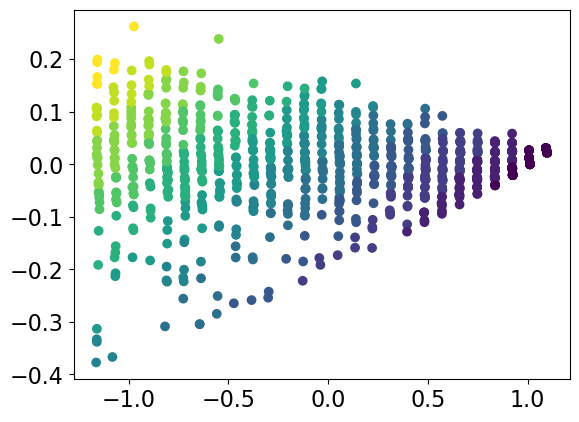

In [5]:
# pca of all embeddings
pca = PCA(n_components=2).fit(embs)
xs, ys = zip(*pca.transform(embs))
cmap = cm.get_cmap("viridis", 12)
colors = [cmap(len(m.edges)/max_n_edges) for m in motifs]
#colors = [cmap(len(m.nodes)/max_n_nodes) for m in motifs]
plt.scatter(xs, ys, color=colors)
plt.show()


接着我们观察嵌入与图大小之间的关系，分别按节点数和边数两种尺度来衡量。可以看到：
- 每个图大小对应的最小嵌入范数大致随规模增长，这和 margin-based 的序嵌入目标一致。
- 在同一图大小下仍然存在变化，说明模型不仅仅依赖图规模，还捕获了其它结构信息。
- 以边数衡量时变化更明显，这也符合节点诱导子图的设定。

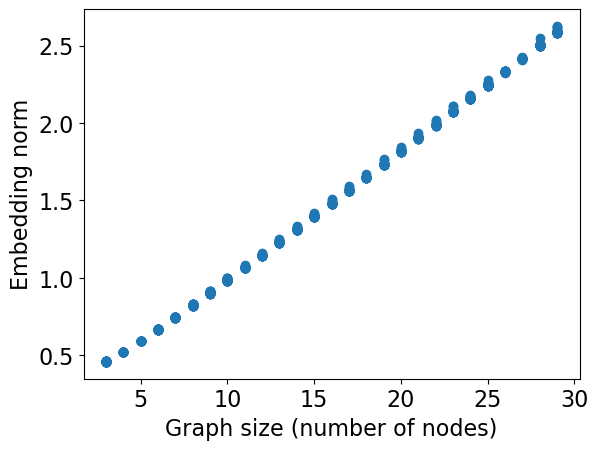

In [6]:
# plot norm vs number of nodes
xs, ys = [len(m) for m in motifs], [np.linalg.norm(emb) for emb in embs]
plt.scatter(xs, ys)
plt.xlabel("Graph size (number of nodes)")
plt.ylabel("Embedding norm")
plt.show()

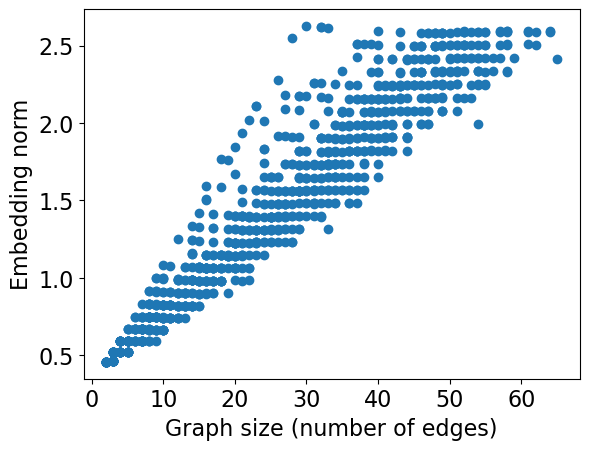

In [7]:
# plot norm vs number of edges
xs, ys = [len(m.edges) for m in motifs], [np.linalg.norm(emb) for emb in embs]
plt.scatter(xs, ys)
plt.xlabel("Graph size (number of edges)")
plt.ylabel("Embedding norm")
plt.show()


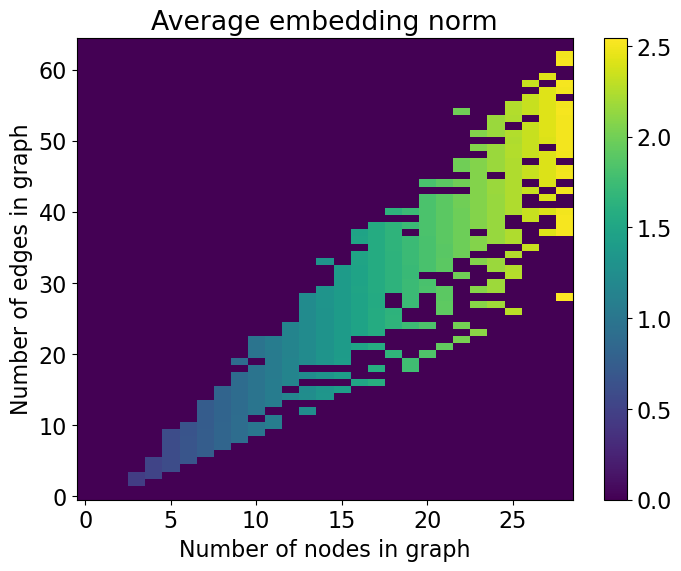

In [10]:
# heatmap of node size vs edge size vs embedding norm
a = defaultdict(lambda: defaultdict(list))
for m, emb in zip(motifs, embs):
    a[len(m)][len(m.edges)].append(np.linalg.norm(emb))
a_mat = np.zeros((max_n_edges, max_n_nodes))
for i in range(max_n_nodes):
    for j in range(max_n_edges):
        a_mat[j][i] = np.mean(a[i][j] if a[i][j] else 0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(a_mat, origin='upper', aspect='auto', cmap='viridis')
ax.invert_yaxis()
ax.set_xlabel("Number of nodes in graph")
ax.set_ylabel("Number of edges in graph")
ax.set_title("Average embedding norm")
fig.colorbar(im, ax=ax)
plt.show()
